# Text Ratio Analysis (Multi-Model)

This notebook analyzes the output JSON files from hf_evaluator.py to:
1. Compute accuracy across different conditions for **multiple models**
2. Calculate text ratios by comparing predictions from three conditions:
   - **img_text**: Image + different text types (corrupted/match/irrelevant)
   - **only_img**: Image + original question (baseline)
   - **only_text**: No image + different text types
3. Determine whether each model follows image or text information

Bar plots show models on x-axis with grouped sub-bars per text type.

In [17]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
import os
import sys

sys.path.insert(0, os.path.abspath('..'))

# Styling to match paper (arxiv 2503.02199) and performance_models.ipynb
sns.set_context('talk', font_scale=1.3)
sns.set_style('whitegrid')
sns.set_palette('colorblind')
plt.rcParams.update({'font.size': 15})

# Text type display name mapping (same as original notebook)
TEXT_TYPE_MAPPING = {
    'corrupted': 'Corruption',
    'match': 'Match',
    'irrelevant': 'Irrelevance',
}

## Configuration

In [18]:
RESULTS_DIR = Path('../results')
DATASET = 'VQAv2'
SUBSET = 'VQAv2'
MAX_SAMPLES = 100
SEED = 0

# Multiple models to compare
MODEL_NAMES = [
    'gpt-4o',
    'Qwen/Qwen3-VL-2B-Instruct',
    # 'claude-opus-4-1-20250805',
    # 'gpt-5-nano',
    # 'claude-opus-4-5-20251101',
    # 'claude-sonnet-4-5-20250929',
    # 'claude-haiku-4-5-20251001',
]

# Short display names for plots (same order as MODEL_NAMES)
# Set to None to auto-generate from MODEL_NAMES
MODEL_DISPLAY_NAMES = None

# Text types to compare against original baseline
TEXT_TYPES = ['corrupted', 'match', 'irrelevant']

## Helper Functions

In [19]:
def load_jsonl(file_path):
    """Load JSONL file and return list of records."""
    records = []
    with open(file_path, 'r') as f:
        for line in f:
            records.append(json.loads(line))
    return records

def compute_accuracy(records):
    """Compute accuracy from records."""
    if not records:
        return 0.0
    correct = sum(1 for r in records if r.get('is_correct', False))
    return correct / len(records)

def normalize_answer(answer):
    """Normalize answer for comparison."""
    if not isinstance(answer, str):
        answer = str(answer)
    return answer.lower().strip().rstrip('.')

def check_answer_similarity(ans1, ans2):
    """Check if two answers are similar (exact match after normalization)."""
    return normalize_answer(ans1) == normalize_answer(ans2)

def build_file_path(results_dir, model_name, subset, input_type, max_samples, seed, text_type):
    """Build file path based on naming convention in hf_evaluator.py."""
    model_dir = results_dir / model_name.replace('/', '_').replace(':', '_')
    subset_str = f"{subset}_" if subset else ""
    filename = f"{subset_str}{input_type}_{max_samples}samples_seed{seed}_{text_type}.jsonl"
    return model_dir / filename

def get_display_name(model_name):
    """Generate a short display name from the full model name."""
    # e.g. 'claude-opus-4-1-20250805' -> 'opus-4-1'
    parts = model_name.split('-')
    # Try to extract family + version
    if 'claude' in model_name:
        # remove 'claude' prefix and date suffix
        name_parts = [p for p in parts if p != 'claude' and not (len(p) == 8 and p.isdigit())]
        return '-'.join(name_parts)
    return model_name[:20]

# Build display names
if MODEL_DISPLAY_NAMES is None:
    MODEL_DISPLAY_NAMES = [get_display_name(m) for m in MODEL_NAMES]

print("Models to analyze:")
for full, short in zip(MODEL_NAMES, MODEL_DISPLAY_NAMES):
    print(f"  {short} ({full})")

Models to analyze:
  gpt-4o (gpt-4o)
  Qwen/Qwen3-VL-2B-Ins (Qwen/Qwen3-VL-2B-Instruct)


## Load Data for All Models

In [20]:
# all_data[model_name] = {'only_img': [...], text_type: {'img_text': [...], 'only_text': [...]}}
all_data = {}

for model_name in MODEL_NAMES:
    print(f"\n{'='*60}")
    print(f"Loading data for: {model_name}")
    print(f"{'='*60}")
    
    model_data = {}
    
    # Baseline: image + original question
    only_img_path = build_file_path(RESULTS_DIR, model_name, SUBSET, 'textplusimage', MAX_SAMPLES, SEED, 'original')
    if only_img_path.exists():
        model_data['only_img'] = load_jsonl(only_img_path)
        print(f"  Loaded baseline (img+original): {len(model_data['only_img'])} records")
    else:
        model_data['only_img'] = []
        print(f"  WARNING: Baseline not found: {only_img_path}")
    
    # Each text type
    for text_type in TEXT_TYPES:
        model_data[text_type] = {}
        
        # img_text: image + text_type
        img_text_path = build_file_path(RESULTS_DIR, model_name, SUBSET, 'textplusimage', MAX_SAMPLES, SEED, text_type)
        if img_text_path.exists():
            model_data[text_type]['img_text'] = load_jsonl(img_text_path)
            print(f"  Loaded img_text ({text_type}): {len(model_data[text_type]['img_text'])} records")
        else:
            model_data[text_type]['img_text'] = []
            print(f"  WARNING: img_text ({text_type}) not found")
        
        # only_text: no image + text_type
        only_text_path = build_file_path(RESULTS_DIR, model_name, SUBSET, 'text-only', MAX_SAMPLES, SEED, text_type)
        if only_text_path.exists():
            model_data[text_type]['only_text'] = load_jsonl(only_text_path)
            print(f"  Loaded only_text ({text_type}): {len(model_data[text_type]['only_text'])} records")
        else:
            model_data[text_type]['only_text'] = []
            print(f"  WARNING: only_text ({text_type}) not found")
    
    all_data[model_name] = model_data


Loading data for: gpt-4o
  Loaded baseline (img+original): 100 records
  Loaded img_text (corrupted): 100 records
  Loaded only_text (corrupted): 100 records
  Loaded img_text (match): 100 records
  Loaded only_text (match): 100 records
  Loaded img_text (irrelevant): 100 records
  Loaded only_text (irrelevant): 100 records

Loading data for: Qwen/Qwen3-VL-2B-Instruct
  Loaded baseline (img+original): 100 records
  Loaded img_text (corrupted): 100 records
  Loaded only_text (corrupted): 100 records
  Loaded img_text (match): 100 records
  Loaded only_text (match): 100 records
  Loaded img_text (irrelevant): 100 records
  Loaded only_text (irrelevant): 100 records


## Compute Accuracy for All Models

In [21]:
accuracy_results = []

for model_name, display_name in zip(MODEL_NAMES, MODEL_DISPLAY_NAMES):
    md = all_data[model_name]
    
    # Baseline accuracy
    if md['only_img']:
        accuracy_results.append({
            'model': display_name,
            'condition': 'img + original',
            'text_type': 'original',
            'accuracy': compute_accuracy(md['only_img']),
            'num_samples': len(md['only_img'])
        })
    
    for text_type in TEXT_TYPES:
        if md[text_type]['img_text']:
            accuracy_results.append({
                'model': display_name,
                'condition': f'img + {text_type}',
                'text_type': text_type,
                'accuracy': compute_accuracy(md[text_type]['img_text']),
                'num_samples': len(md[text_type]['img_text'])
            })
        if md[text_type]['only_text']:
            accuracy_results.append({
                'model': display_name,
                'condition': f'text-only + {text_type}',
                'text_type': text_type,
                'accuracy': compute_accuracy(md[text_type]['only_text']),
                'num_samples': len(md[text_type]['only_text'])
            })

acc_df = pd.DataFrame(accuracy_results)
print("\nAccuracy Results:")
print(acc_df.to_string(index=False))


Accuracy Results:
               model              condition  text_type  accuracy  num_samples
              gpt-4o         img + original   original      0.70          100
              gpt-4o        img + corrupted  corrupted      0.45          100
              gpt-4o  text-only + corrupted  corrupted      0.02          100
              gpt-4o            img + match      match      0.87          100
              gpt-4o      text-only + match      match      0.88          100
              gpt-4o       img + irrelevant irrelevant      0.68          100
              gpt-4o text-only + irrelevant irrelevant      0.21          100
Qwen/Qwen3-VL-2B-Ins         img + original   original      0.73          100
Qwen/Qwen3-VL-2B-Ins        img + corrupted  corrupted      0.39          100
Qwen/Qwen3-VL-2B-Ins  text-only + corrupted  corrupted      0.02          100
Qwen/Qwen3-VL-2B-Ins            img + match      match      0.91          100
Qwen/Qwen3-VL-2B-Ins      text-only + match  

## Visualize Accuracy

Grouped bar plot: x-axis = model, sub-bars = condition

/var/folders/4f/2ygrgplj2cvb24vwr0423y8r0000gn/T/ipykernel_68249/1344627395.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=12)


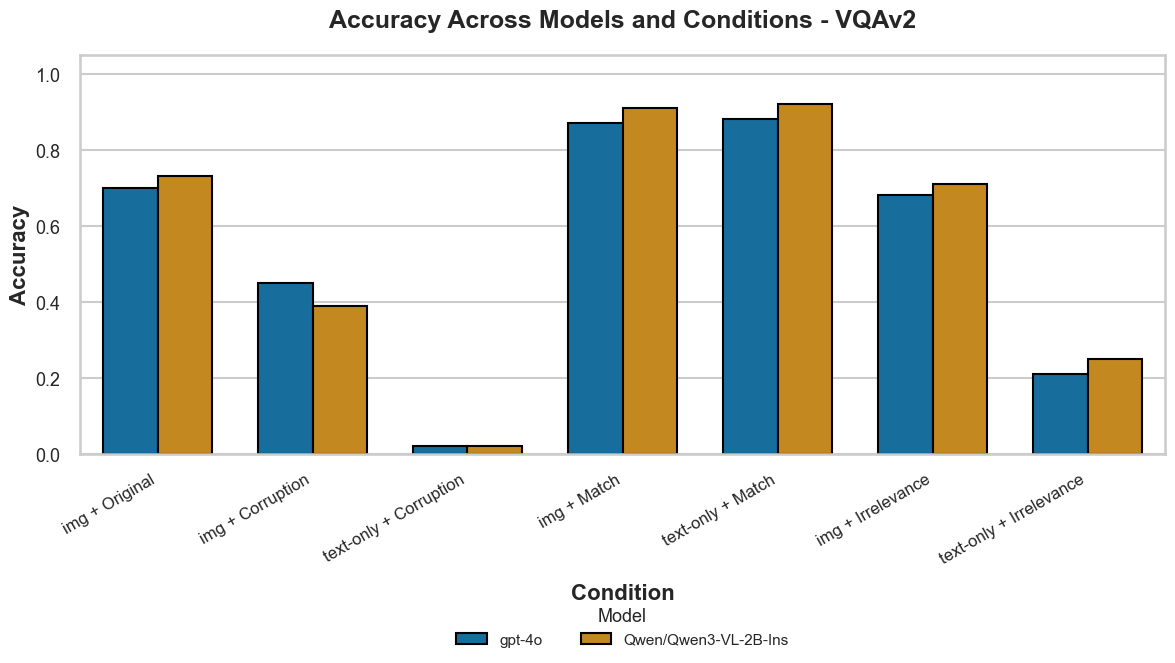

In [22]:
if not acc_df.empty:
    # Map text_type to display names for plotting
    acc_plot = acc_df.copy()
    acc_plot['condition_display'] = acc_plot['condition'].replace({
        'img + corrupted': 'img + Corruption',
        'img + match': 'img + Match',
        'img + irrelevant': 'img + Irrelevance',
        'text-only + corrupted': 'text-only + Corruption',
        'text-only + match': 'text-only + Match',
        'text-only + irrelevant': 'text-only + Irrelevance',
        'img + original': 'img + Original',
    })

    # Order conditions so original is first, then grouped by text type
    condition_order = [
        'img + Original',
        'img + Corruption', 'text-only + Corruption',
        'img + Match', 'text-only + Match',
        'img + Irrelevance', 'text-only + Irrelevance',
    ]
    # Keep only conditions present in data
    condition_order = [c for c in condition_order if c in acc_plot['condition_display'].values]

    fig, ax = plt.subplots(figsize=(max(14, len(condition_order) * 2), 7))
    # Swap: x=condition, hue=model — lets models be compared side-by-side per condition
    sns.barplot(ax=ax, data=acc_plot, x='condition_display', y='accuracy', hue='model',
                order=condition_order, hue_order=MODEL_DISPLAY_NAMES,
                width=0.7, linewidth=1.5, edgecolor='black')
    ax.set_ylabel('Accuracy', fontweight='bold', fontsize=16)
    ax.set_xlabel('Condition', fontweight='bold', fontsize=16, labelpad=12)
    ax.set_title(f'Accuracy Across Models and Conditions - {DATASET}',
                 fontweight='bold', fontsize=18, pad=20)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=12)
    ax.tick_params(axis='y', labelsize=13, pad=5)
    ax.set_ylim(0, 1.05)
    legend = ax.legend(title='Model', title_fontsize=13, fontsize=11,
                       loc='upper center', bbox_to_anchor=(0.5, -0.35),
                       ncol=len(MODEL_DISPLAY_NAMES), frameon=False,
                       columnspacing=2.5, handletextpad=0.8, handlelength=2.0)
    plt.subplots_adjust(bottom=0.35, top=0.92)
    plt.show()
else:
    print("No accuracy data available.")

## Compute Text Ratios

For each non-original text type, compare three conditions per question:
- **img_text** prediction (image + corrupted/match/irrelevant text)
- **only_img** prediction (image + original question, baseline)
- **only_text** prediction (no image + corrupted/match/irrelevant text)

If img_text prediction matches only_text -> model follows **text**  
If img_text prediction matches only_img -> model follows **image**

In [23]:
def compute_text_ratio(only_img_records, img_text_records, only_text_records):
    """
    Compute text ratio by comparing img_text predictions against
    only_img (image baseline) and only_text (text baseline).
    """
    only_img_by_qid = {r['question_id']: r for r in only_img_records}
    img_text_by_qid = {r['question_id']: r for r in img_text_records}
    only_text_by_qid = {r['question_id']: r for r in only_text_records}
    
    common_qids = (set(only_img_by_qid.keys()) &
                   set(img_text_by_qid.keys()) &
                   set(only_text_by_qid.keys()))
    
    use_img_count = 0
    use_text_count = 0
    both_count = 0
    neither_count = 0
    details = []
    
    for qid in common_qids:
        img_text_pred = img_text_by_qid[qid].get('pred_answer', '')
        only_img_pred = only_img_by_qid[qid].get('pred_answer', '')
        only_text_pred = only_text_by_qid[qid].get('pred_answer', '')
        
        matches_img = check_answer_similarity(img_text_pred, only_img_pred)
        matches_text = check_answer_similarity(img_text_pred, only_text_pred)
        
        if matches_img and matches_text:
            status = 'both'
            both_count += 1
        elif matches_img and not matches_text:
            status = 'img'
            use_img_count += 1
        elif matches_text and not matches_img:
            status = 'text'
            use_text_count += 1
        else:
            status = 'neither'
            neither_count += 1
        
        details.append({
            'question_id': qid,
            'status': status,
            'img_text_pred': img_text_pred,
            'only_img_pred': only_img_pred,
            'only_text_pred': only_text_pred,
            'img_text_correct': img_text_by_qid[qid].get('is_correct', False),
            'only_img_correct': only_img_by_qid[qid].get('is_correct', False),
            'only_text_correct': only_text_by_qid[qid].get('is_correct', False),
        })
    
    total_discriminative = use_img_count + use_text_count
    text_ratio = use_text_count / total_discriminative if total_discriminative > 0 else np.nan
    
    total_coarse = use_img_count + use_text_count + both_count
    coarse_text_ratio = (use_text_count + both_count) / total_coarse if total_coarse > 0 else np.nan
    
    return {
        'use_img_count': use_img_count,
        'use_text_count': use_text_count,
        'both_count': both_count,
        'neither_count': neither_count,
        'total_questions': len(common_qids),
        'text_ratio': text_ratio,
        'coarse_text_ratio': coarse_text_ratio,
        'details': details
    }

In [24]:
# Compute text ratios for all models x text types
ratio_results = []
all_details = []

for model_name, display_name in zip(MODEL_NAMES, MODEL_DISPLAY_NAMES):
    md = all_data[model_name]
    print(f"\n{'='*60}")
    print(f"{display_name}")
    print(f"{'='*60}")
    
    for text_type in TEXT_TYPES:
        only_img = md.get('only_img', [])
        img_text = md.get(text_type, {}).get('img_text', [])
        only_text = md.get(text_type, {}).get('only_text', [])
        
        if not only_img or not img_text or not only_text:
            print(f"  Skipping {text_type}: missing data")
            # Append a row with NaN so the bar is simply absent
            ratio_results.append({
                'model': display_name,
                'text_type': text_type,
                'use_img_count': 0,
                'use_text_count': 0,
                'both_count': 0,
                'neither_count': 0,
                'total_questions': 0,
                'text_ratio': np.nan,
                'coarse_text_ratio': np.nan,
            })
            continue
        
        result = compute_text_ratio(only_img, img_text, only_text)
        result['model'] = display_name
        result['text_type'] = text_type
        
        # Collect details
        for detail in result['details']:
            detail['model'] = display_name
            detail['text_type'] = text_type
            all_details.append(detail)
        
        ratio_results.append({k: v for k, v in result.items() if k != 'details'})
        
        print(f"  {text_type}: follows_img={result['use_img_count']}, "
              f"follows_text={result['use_text_count']}, "
              f"both={result['both_count']}, neither={result['neither_count']}, "
              f"text_ratio={result['text_ratio']:.3f}")

pref_df = pd.DataFrame(ratio_results)
details_df = pd.DataFrame(all_details) if all_details else pd.DataFrame()

print("\n" + "="*60)
print("Text Ratio Summary:")
print("="*60)
print(pref_df.to_string(index=False))


gpt-4o
  corrupted: follows_img=43, follows_text=22, both=4, neither=30, text_ratio=0.338
  match: follows_img=7, follows_text=23, both=62, neither=7, text_ratio=0.767
  irrelevant: follows_img=79, follows_text=0, both=4, neither=16, text_ratio=0.000

Qwen/Qwen3-VL-2B-Ins
  corrupted: follows_img=40, follows_text=41, both=7, neither=11, text_ratio=0.506
  match: follows_img=5, follows_text=22, both=67, neither=5, text_ratio=0.815
  irrelevant: follows_img=61, follows_text=3, both=22, neither=13, text_ratio=0.047

Text Ratio Summary:
 use_img_count  use_text_count  both_count  neither_count  total_questions  text_ratio  coarse_text_ratio                model  text_type
            43              22           4             30               99    0.338462           0.376812               gpt-4o  corrupted
             7              23          62              7               99    0.766667           0.923913               gpt-4o      match
            79               0           4    

## TPR Bar Plot (Text Preference Ratio)

X-axis = model, grouped sub-bars = text condition (Match / Corruption / Irrelevance).
Matches Figure style from the paper.

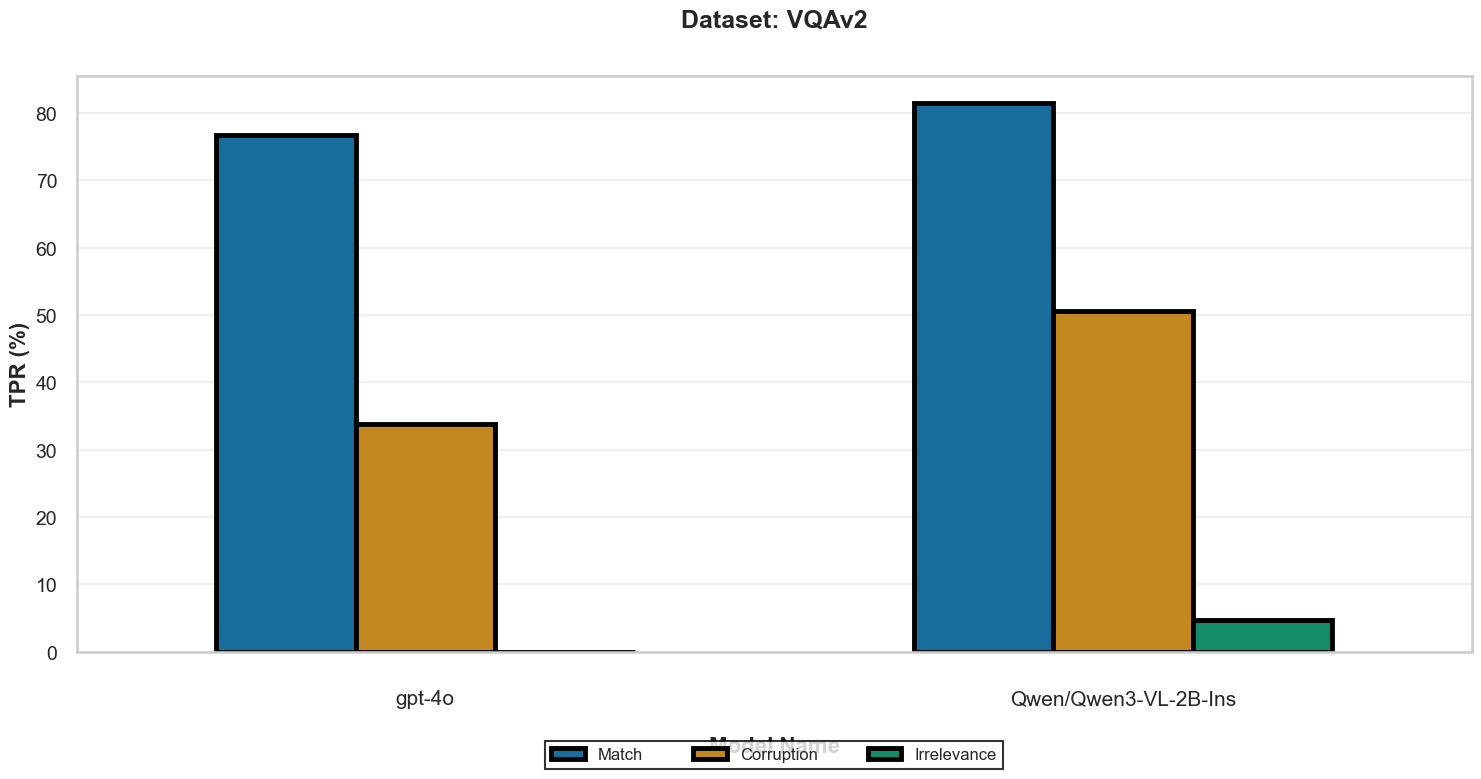

In [25]:
# Prepare data for sns.barplot: use display names for text types, TPR in %
tpr_plot_df = pref_df.copy()
tpr_plot_df['prompt'] = tpr_plot_df['text_type'].map(TEXT_TYPE_MAPPING)
tpr_plot_df['TPR'] = tpr_plot_df['text_ratio'] * 100  # Convert to percentage

# Drop rows with no data
tpr_plot_df = tpr_plot_df.dropna(subset=['TPR'])

hue_order = ['Match', 'Corruption', 'Irrelevance']
# Only keep hue values that exist in data
hue_order = [h for h in hue_order if h in tpr_plot_df['prompt'].values]

if not tpr_plot_df.empty:
    # Use whitegrid style for background grid lines
    sns.set_style('whitegrid')
    
    fig, ax = plt.subplots(figsize=(max(18, len(MODEL_NAMES) * 6), 8))
    sns.barplot(ax=ax, data=tpr_plot_df, x='model', y='TPR', hue='prompt',
                width=0.6, hue_order=hue_order,
                linewidth=3.5, edgecolor='black')
    
    ax.set_title(f'Dataset: {DATASET}', fontweight='bold', fontsize=18, pad=35)
    ax.set_ylabel('TPR (%)', fontweight='bold', fontsize=16)
    ax.set_xlabel('Model Name', fontweight='bold', fontsize=16, labelpad=20)
    ax.tick_params(axis='x', labelsize=15, pad=18)
    ax.tick_params(axis='y', labelsize=14, pad=5)
    ax.grid(True, axis='y', alpha=0.3)  # Ensure grid lines are visible
    # Legend with frame, no title
    legend = ax.legend(fontsize=12, loc='upper center', bbox_to_anchor=(0.5, -0.14), 
                       ncols=3, frameon=True, columnspacing=3.0,
                       handletextpad=0.8, handlelength=2.0, labelspacing=0.8,
                       edgecolor='black', fancybox=False)
    legend.get_frame().set_linewidth(1.5)
    plt.subplots_adjust(bottom=0.20, top=0.92)
    plt.show()
else:
    print("No TPR data available.")

## Horizontal Stacked Bar + TPR Scatter (Paper Style)

For each text condition: horizontal stacked bars showing Image / Other / Text proportions,
with a TPR scatter plot on the right. Models sorted by TPR.

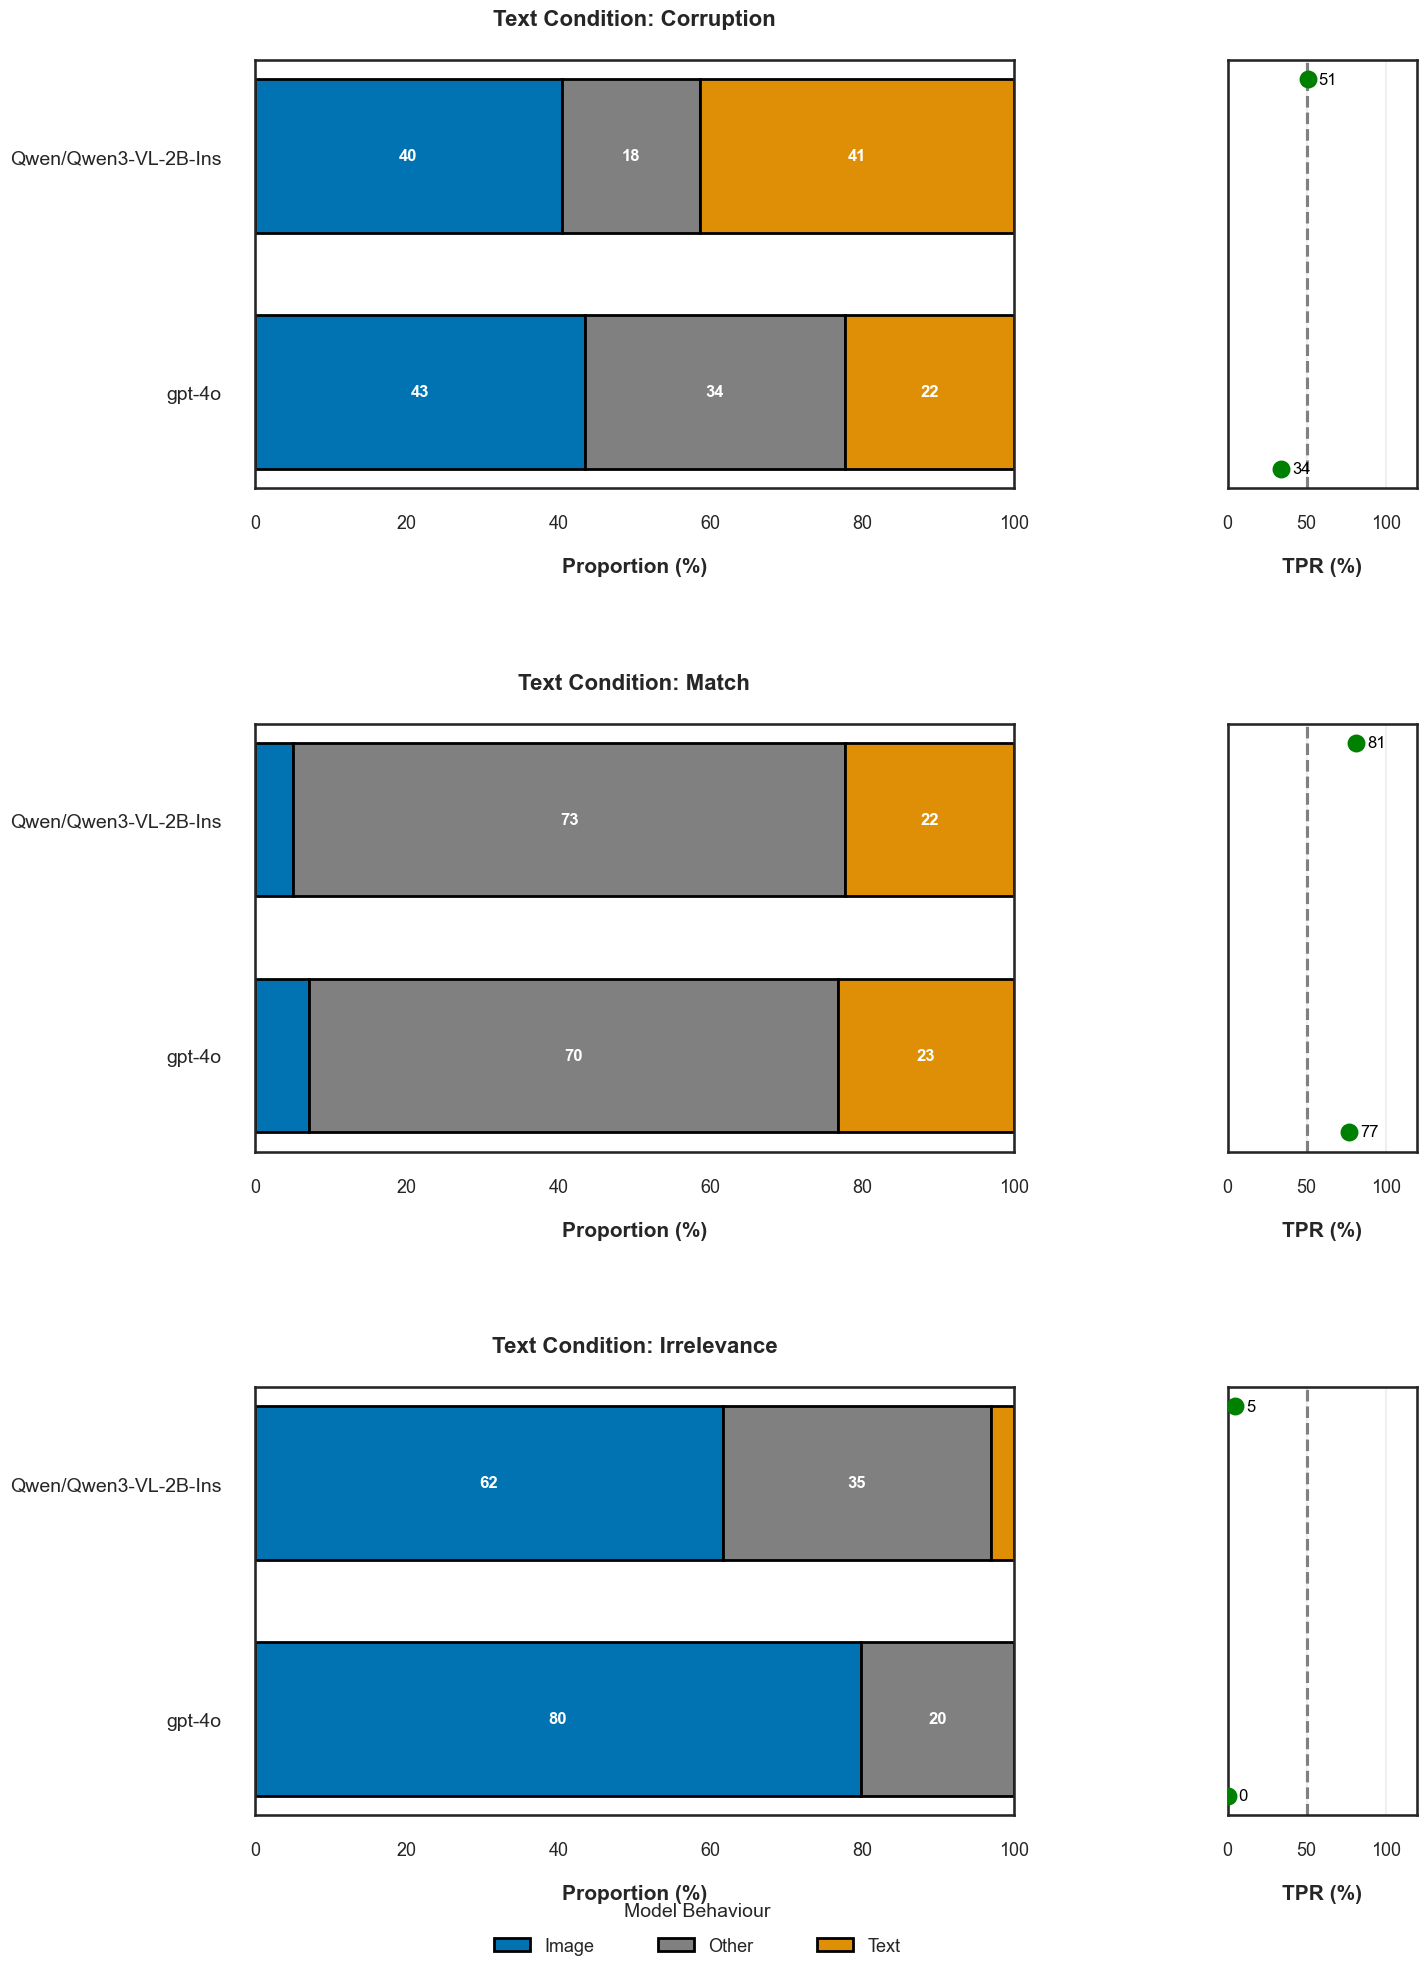

In [26]:
sns.set_context("talk", font_scale=1.0)
sns.set_style("white")
plt.rcParams.update({'font.size': 15})
sns.set_palette("colorblind")

ordered_prompts = [t for t in TEXT_TYPES if pref_df[pref_df['text_type'] == t]['total_questions'].sum() > 0]

if ordered_prompts:
    fig, axs = plt.subplots(nrows=len(ordered_prompts), ncols=2,
                            figsize=(15, 6.5 * len(ordered_prompts)),
                            gridspec_kw={'width_ratios': [4, 1], 'hspace': 0.55, 'wspace': 0.45})
    if len(ordered_prompts) == 1:
        axs = axs.reshape(1, -1)

    for idx, text_type in enumerate(ordered_prompts):
        ax1 = axs[idx, 0]
        ax2 = axs[idx, 1]

        sub = pref_df[pref_df['text_type'] == text_type].copy()
        sub = sub[sub['total_questions'] > 0]
        if sub.empty:
            continue

        # Compute percentages
        sub['img_pct'] = sub['use_img_count'] / sub['total_questions'] * 100
        sub['text_pct'] = sub['use_text_count'] / sub['total_questions'] * 100
        sub['other_pct'] = (sub['both_count'] + sub['neither_count']) / sub['total_questions'] * 100
        sub['TPR'] = sub['use_text_count'] / (sub['use_img_count'] + sub['use_text_count']) * 100
        sub['TPR'] = sub['TPR'].fillna(0)

        # Sort by TPR ascending
        sub = sub.sort_values(by='TPR', ascending=True).reset_index(drop=True)
        labels = sub['model']

        # Left: Horizontal stacked bar chart
        bar1 = ax1.barh(labels, sub['img_pct'], color='C0', label='Image',
                        height=0.65, alpha=1, linewidth=2, edgecolor='black')
        bar2 = ax1.barh(labels, sub['other_pct'], left=sub['img_pct'], color='gray', label='Other',
                        height=0.65, alpha=1, linewidth=2, edgecolor='black')
        bar3 = ax1.barh(labels, sub['text_pct'], left=sub['img_pct'] + sub['other_pct'],
                        color='C1', label='Text',
                        height=0.65, alpha=1, linewidth=2, edgecolor='black')

        # Add text labels inside the bars
        for bar_group in [bar1, bar2, bar3]:
            for bar in bar_group:
                width = bar.get_width()
                if width > 12:
                    ax1.text(bar.get_x() + width / 2, bar.get_y() + bar.get_height() / 2,
                             f'{width:.0f}', ha='center', va='center', color='white', 
                             fontweight='bold', fontsize=12)

        ax1.set_xlim([0, 100])
        ax1.set_xlabel('Proportion (%)', fontweight='bold', fontsize=15, labelpad=18)
        ax1.set_title(f'Text Condition: {TEXT_TYPE_MAPPING.get(text_type, text_type)}', 
                      fontweight='bold', fontsize=16, pad=25)
        ax1.tick_params(axis='y', pad=15, labelsize=14)
        ax1.tick_params(axis='x', labelsize=13, pad=10)

        # Right: Scatter plot for TPR
        ax2.scatter(sub['TPR'], labels, color='green', s=130, zorder=3)

        for i, value in enumerate(sub['TPR']):
            ax2.text(value + 7, i, f'{value:.0f}', va='center', ha='left', 
                     color='black', fontsize=12)

        ax2.set_xlim(0, 120)
        ax2.axvline(50, color='gray', linestyle='--', zorder=1)
        ax2.set_xlabel('TPR (%)', fontweight='bold', fontsize=15, labelpad=18)
        ax2.set_yticklabels([])
        ax2.tick_params(axis='x', labelsize=13, pad=10)
        ax2.grid(axis='x', alpha=0.3)

    # Shared legend at the bottom
    handles, lbls = axs[0, 0].get_legend_handles_labels()
    legend = fig.legend(handles, lbls, title='Model Behaviour', 
                        title_fontsize=14, fontsize=13,
                        loc='lower center', bbox_to_anchor=(0.42, -0.02), 
                        ncol=3, frameon=False, columnspacing=3.5,
                        handletextpad=0.8, handlelength=2.0, labelspacing=0.8)
    legend._legend_box.sep = 12
    plt.subplots_adjust(bottom=0.06, top=0.96)
    plt.show()
else:
    print("No data available for stacked bar chart.")

## Detailed Question-Level Analysis

In [27]:
if not details_df.empty:
    print(f"Total question-level records: {len(details_df)}")
    
    # Show examples where model follows text
    follows_text = details_df[details_df['status'] == 'text']
    print(f"\nQuestions where model follows text: {len(follows_text)}")
    if len(follows_text) > 0:
        print("\nSample (model follows text):")
        print(follows_text.head(10)[['model', 'text_type', 'question_id',
                                     'img_text_pred', 'only_img_pred', 'only_text_pred']])
    
    # Show examples where model follows image
    follows_img = details_df[details_df['status'] == 'img']
    print(f"\nQuestions where model follows image: {len(follows_img)}")
    if len(follows_img) > 0:
        print("\nSample (model follows image):")
        print(follows_img.head(10)[['model', 'text_type', 'question_id',
                                    'img_text_pred', 'only_img_pred', 'only_text_pred']])
else:
    print("No detail records available.")

Total question-level records: 594

Questions where model follows text: 111

Sample (model follows text):
     model  text_type                                        question_id  \
5   gpt-4o  corrupted  How many pringles cans are on top of the fridg...   
8   gpt-4o  corrupted  If I turn left at the light, what street will ...   
15  gpt-4o  corrupted         What is the young man carrying?/['camera']   
18  gpt-4o  corrupted   Does the bear have anything to play with?/['no']   
32  gpt-4o  corrupted   How many different colors are in this tie?/['4']   
38  gpt-4o  corrupted             What time is it on the clock?/['5:10']   
45  gpt-4o  corrupted                  How many jockeys are there?/['3']   
49  gpt-4o  corrupted                    Is one bus tire turned?/['yes']   
50  gpt-4o  corrupted                               How many cats?/['0']   
53  gpt-4o  corrupted  Does the man have both feet on the ground?/['y...   

    img_text_pred only_img_pred only_text_pred  
5        

## Confidence-Binned Heatmap (Paper Style)

For models that provide logprobs, plot 1×3 heatmaps (Image / Text / Other proportion)
binned by Image Certainty (y-axis) and Text Certainty (x-axis) using quantile-based bins.

Confidence = exp(mean(logprobs)) following the paper's approach.

**Note:** Claude models don't provide logprobs, so they are skipped automatically.

In [29]:
import ast

def get_confidence(logprobs):
    """Convert logprobs list to a confidence score (matching paper)."""
    return np.exp(np.mean(logprobs))

def parse_logprobs(raw):
    """Parse logprobs from JSONL record into a list of floats, or None."""
    if raw is None or raw == 'None' or raw == 'MISSING':
        return None
    if isinstance(raw, list):
        try:
            return [float(v) for v in raw]
        except (ValueError, TypeError):
            return None
    if isinstance(raw, str):
        try:
            parsed = ast.literal_eval(raw)
            if isinstance(parsed, list):
                return [float(v) for v in parsed]
        except Exception:
            pass
    return None


# Build confidence data for each model x text_type
# For each question we need:
#   img_conf  = confidence from only_img (image + original)
#   text_conf = confidence from only_text (text-only + text_type)
#   use_img, use_text, use_other = from the status we already computed

conf_data = {}  # conf_data[display_name][text_type] = dict of arrays

for model_name, display_name in zip(MODEL_NAMES, MODEL_DISPLAY_NAMES):
    md = all_data[model_name]
    conf_data[display_name] = {}
    
    for text_type in TEXT_TYPES:
        only_img = md.get('only_img', [])
        img_text = md.get(text_type, {}).get('img_text', [])
        only_text = md.get(text_type, {}).get('only_text', [])
        
        if not only_img or not img_text or not only_text:
            continue
        
        # Index records by question_id
        only_img_by_qid = {r['question_id']: r for r in only_img}
        img_text_by_qid = {r['question_id']: r for r in img_text}
        only_text_by_qid = {r['question_id']: r for r in only_text}
        common_qids = (set(only_img_by_qid) & set(img_text_by_qid) & set(only_text_by_qid))
        
        img_confs = []
        text_confs = []
        use_imgs = []
        use_texts = []
        use_others = []
        skipped = 0
        
        for qid in common_qids:
            img_lp = parse_logprobs(only_img_by_qid[qid].get('logprobs'))
            text_lp = parse_logprobs(only_text_by_qid[qid].get('logprobs'))
            
            if img_lp is None or text_lp is None or len(img_lp) == 0 or len(text_lp) == 0:
                skipped += 1
                continue
            
            img_confs.append(get_confidence(img_lp))
            text_confs.append(get_confidence(text_lp))
            
            # Determine status (same logic as compute_text_ratio)
            it_pred = normalize_answer(img_text_by_qid[qid].get('pred_answer', ''))
            oi_pred = normalize_answer(only_img_by_qid[qid].get('pred_answer', ''))
            ot_pred = normalize_answer(only_text_by_qid[qid].get('pred_answer', ''))
            
            matches_img = (it_pred == oi_pred)
            matches_text = (it_pred == ot_pred)
            
            if matches_img and not matches_text:
                use_imgs.append(1); use_texts.append(0); use_others.append(0)
            elif matches_text and not matches_img:
                use_imgs.append(0); use_texts.append(1); use_others.append(0)
            else:
                use_imgs.append(0); use_texts.append(0); use_others.append(1)
        
        if img_confs:
            conf_data[display_name][text_type] = {
                'img_conf': np.array(img_confs),
                'text_conf': np.array(text_confs),
                'use_imgs': np.array(use_imgs),
                'use_texts': np.array(use_texts),
                'use_others': np.array(use_others),
            }
            print(f'{display_name} / {text_type}: {len(img_confs)} samples with confidence (skipped {skipped})')
        else:
            print(f'{display_name} / {text_type}: no logprobs available (skipped {skipped})')


gpt-4o / corrupted: 99 samples with confidence (skipped 0)
gpt-4o / match: 99 samples with confidence (skipped 0)
gpt-4o / irrelevant: 99 samples with confidence (skipped 0)
Qwen/Qwen3-VL-2B-Ins / corrupted: 99 samples with confidence (skipped 0)
Qwen/Qwen3-VL-2B-Ins / match: 99 samples with confidence (skipped 0)
Qwen/Qwen3-VL-2B-Ins / irrelevant: 99 samples with confidence (skipped 0)


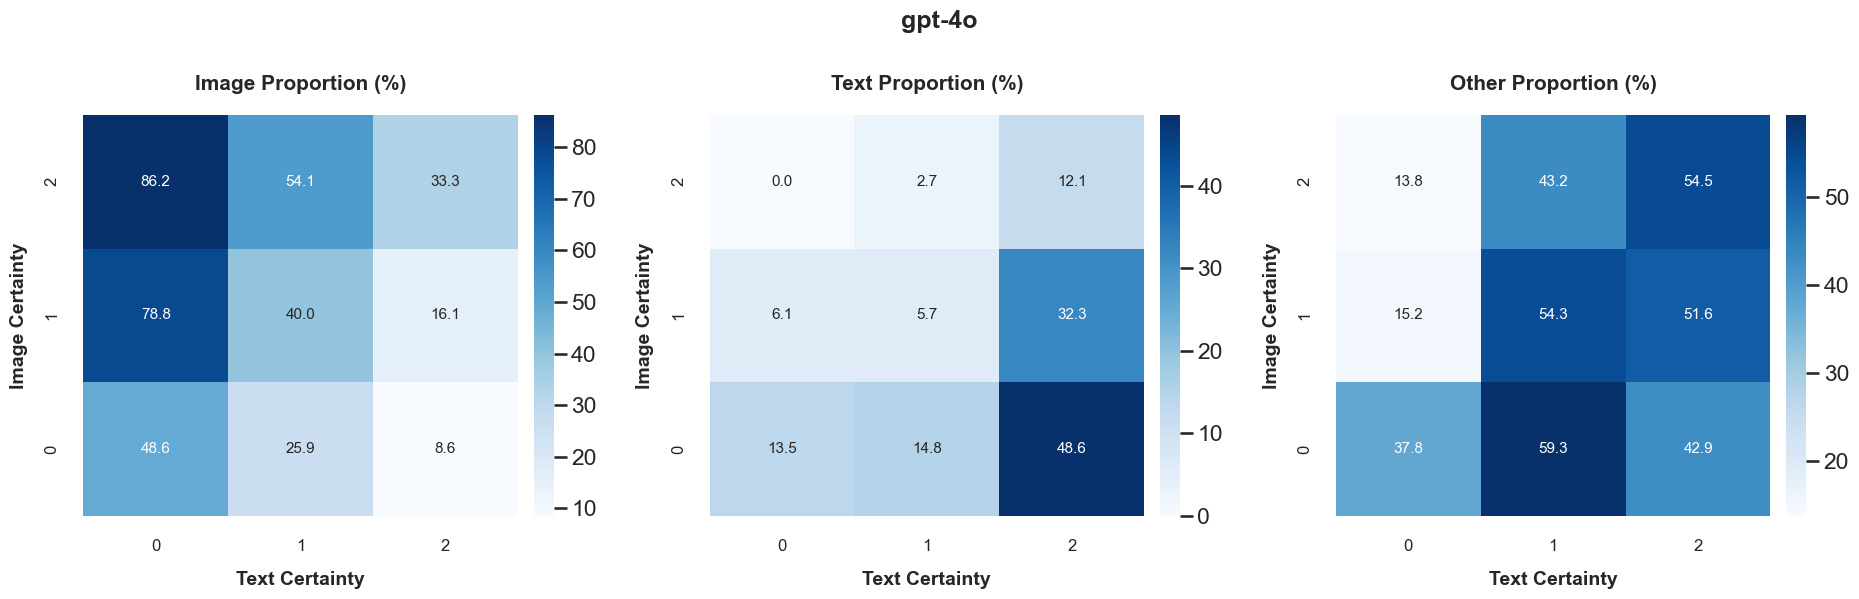

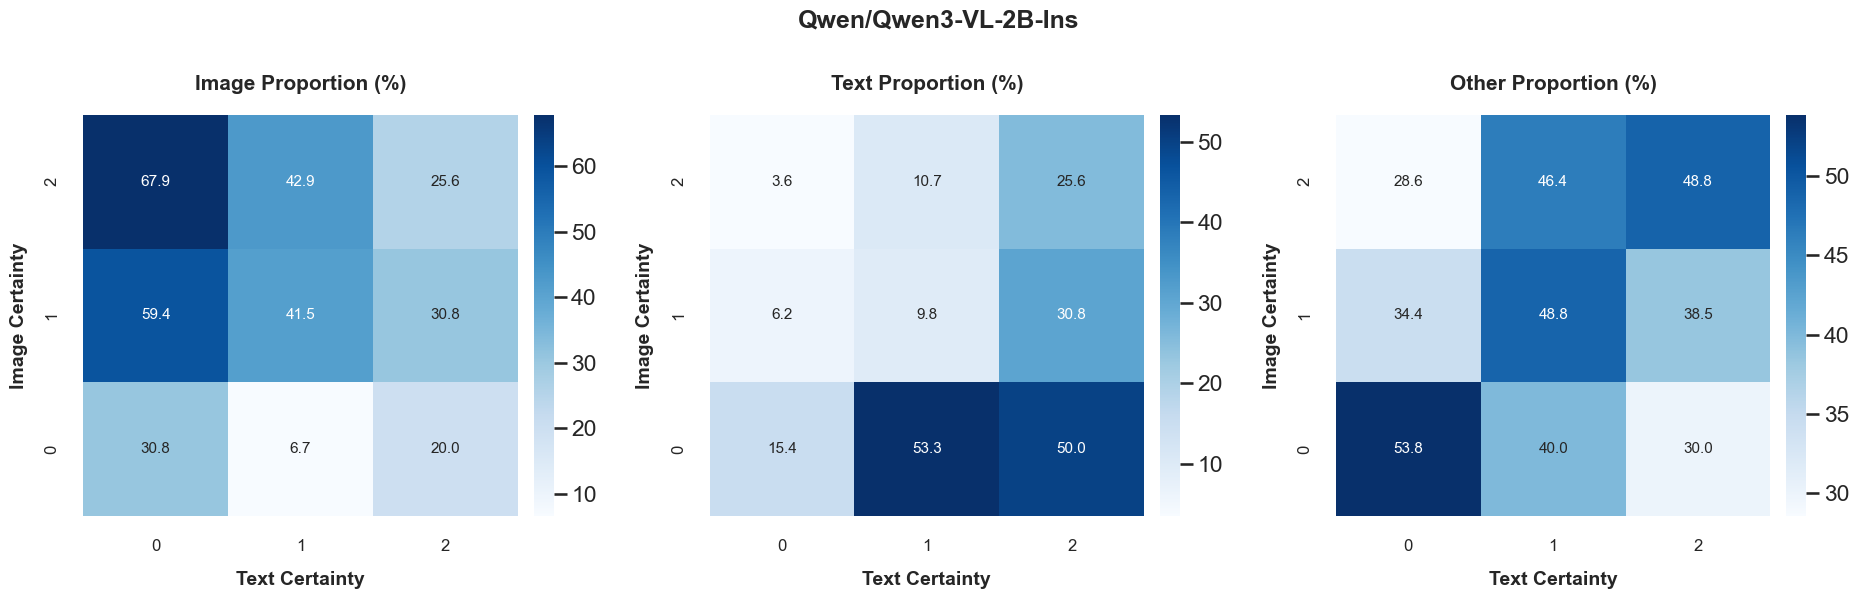

In [30]:
# Confidence-binned heatmap matching paper (performance_models.ipynb cell 22)
bins = 3

sns.set_context('talk')
plt.rcParams.update({'font.size': 14})

for display_name in MODEL_DISPLAY_NAMES:
    model_conf = conf_data.get(display_name, {})
    if not model_conf:
        print(f'{display_name}: no confidence data, skipping heatmap')
        continue
    
    # Concatenate across all text types for this model
    all_img_conf = np.concatenate([d['img_conf'] for d in model_conf.values()])
    all_text_conf = np.concatenate([d['text_conf'] for d in model_conf.values()])
    all_use_imgs = np.concatenate([d['use_imgs'] for d in model_conf.values()])
    all_use_texts = np.concatenate([d['use_texts'] for d in model_conf.values()])
    all_use_others = np.concatenate([d['use_others'] for d in model_conf.values()])
    
    if len(all_img_conf) == 0:
        print(f'{display_name}: empty confidence arrays, skipping')
        continue
    
    # Quantile-based binning
    quantiles = np.linspace(0, 1, bins + 1)
    
    img_conf_q = np.quantile(all_img_conf, quantiles)
    img_conf_q = np.append(img_conf_q, np.inf)
    text_conf_q = np.quantile(all_text_conf, quantiles)
    text_conf_q = np.append(text_conf_q, np.inf)
    
    img_conf_group = np.zeros_like(all_img_conf)
    text_conf_group = np.zeros_like(all_text_conf)
    
    for i in range(bins):
        img_conf_group[(all_img_conf >= img_conf_q[i]) & (all_img_conf < img_conf_q[i+1])] = i
        text_conf_group[(all_text_conf >= text_conf_q[i]) & (all_text_conf < text_conf_q[i+1])] = i
    
    img_conf_group[all_img_conf >= img_conf_q[bins]] = bins - 1
    text_conf_group[all_text_conf >= text_conf_q[bins]] = bins - 1
    
    # Compute ratio grids
    img_ratio_grid = np.zeros((bins, bins))
    text_ratio_grid = np.zeros((bins, bins))
    other_ratio_grid = np.zeros((bins, bins))
    
    for i in range(bins):
        for j in range(bins):
            mask = (img_conf_group == i) & (text_conf_group == j)
            if mask.sum() > 0:
                img_ratio_grid[i, j] = np.mean(all_use_imgs[mask]) * 100
                text_ratio_grid[i, j] = np.mean(all_use_texts[mask]) * 100
                other_ratio_grid[i, j] = np.mean(all_use_others[mask]) * 100
    
    # Plot 1x3 heatmap with better spacing
    fig, ax = plt.subplots(1, 3, figsize=(19, 6))
    
    sns.heatmap(img_ratio_grid, annot=True, ax=ax[0], cmap='Blues', 
                fmt='.1f', annot_kws={'fontsize': 11}, cbar_kws={'pad': 0.03})
    ax[0].set_title('Image Proportion (%)', fontweight='bold', fontsize=15, pad=18)
    ax[0].set_xlabel('Text Certainty', fontweight='bold', fontsize=14, labelpad=12)
    ax[0].set_ylabel('Image Certainty', fontweight='bold', fontsize=14, labelpad=12)
    ax[0].tick_params(pad=8, labelsize=12)
    ax[0].invert_yaxis()
    
    sns.heatmap(text_ratio_grid, annot=True, ax=ax[1], cmap='Blues',
                fmt='.1f', annot_kws={'fontsize': 11}, cbar_kws={'pad': 0.03})
    ax[1].set_title('Text Proportion (%)', fontweight='bold', fontsize=15, pad=18)
    ax[1].set_xlabel('Text Certainty', fontweight='bold', fontsize=14, labelpad=12)
    ax[1].set_ylabel('Image Certainty', fontweight='bold', fontsize=14, labelpad=12)
    ax[1].tick_params(pad=8, labelsize=12)
    ax[1].invert_yaxis()
    
    sns.heatmap(other_ratio_grid, annot=True, ax=ax[2], cmap='Blues',
                fmt='.1f', annot_kws={'fontsize': 11}, cbar_kws={'pad': 0.03})
    ax[2].set_title('Other Proportion (%)', fontweight='bold', fontsize=15, pad=18)
    ax[2].set_xlabel('Text Certainty', fontweight='bold', fontsize=14, labelpad=12)
    ax[2].set_ylabel('Image Certainty', fontweight='bold', fontsize=14, labelpad=12)
    ax[2].tick_params(pad=8, labelsize=12)
    ax[2].invert_yaxis()
    
    plt.suptitle(f'{display_name}', fontweight='bold', fontsize=18, y=1.0)
    plt.subplots_adjust(top=0.92)
    plt.tight_layout()
    plt.show()

## Export Results

In [31]:
output_dir = Path('../analysis_outputs')
output_dir.mkdir(exist_ok=True)

acc_df.to_csv(output_dir / 'accuracy_results.csv', index=False)
print(f"Exported accuracy results to {output_dir / 'accuracy_results.csv'}")

pref_df.to_csv(output_dir / 'text_ratio_results.csv', index=False)
print(f"Exported text ratio results to {output_dir / 'text_ratio_results.csv'}")

if not details_df.empty:
    details_df.to_csv(output_dir / 'detailed_results.csv', index=False)
    print(f"Exported detailed results to {output_dir / 'detailed_results.csv'}")

Exported accuracy results to ../analysis_outputs/accuracy_results.csv
Exported text ratio results to ../analysis_outputs/text_ratio_results.csv
Exported detailed results to ../analysis_outputs/detailed_results.csv


## Summary Report

In [32]:
print("=" * 80)
print("SUMMARY REPORT")
print("=" * 80)
print(f"Dataset: {DATASET}")
print(f"Models: {', '.join(MODEL_DISPLAY_NAMES)}")
print(f"Samples: {MAX_SAMPLES}, Seed: {SEED}")

print("\n" + "=" * 80)
print("ACCURACY")
print("=" * 80)
print(acc_df[['model', 'condition', 'accuracy', 'num_samples']].to_string(index=False))

print("\n" + "=" * 80)
print("TEXT RATIOS")
print("=" * 80)
print(pref_df[['model', 'text_type', 'use_img_count', 'use_text_count',
               'both_count', 'neither_count', 'text_ratio', 'coarse_text_ratio']].to_string(index=False))

print("\n" + "=" * 80)
print("KEY FINDINGS")
print("=" * 80)
for _, row in pref_df.iterrows():
    if np.isnan(row['text_ratio']):
        print(f"  {row['model']} / {row['text_type']}: NO DATA")
    elif row['text_ratio'] > 0.5:
        print(f"  {row['model']} / {row['text_type']}: tends to FOLLOW TEXT (ratio={row['text_ratio']:.3f})")
    elif row['text_ratio'] < 0.5:
        print(f"  {row['model']} / {row['text_type']}: tends to FOLLOW IMAGE (ratio={row['text_ratio']:.3f})")
    else:
        print(f"  {row['model']} / {row['text_type']}: BALANCED (ratio={row['text_ratio']:.3f})")
print("=" * 80)

SUMMARY REPORT
Dataset: VQAv2
Models: gpt-4o, Qwen/Qwen3-VL-2B-Ins
Samples: 100, Seed: 0

ACCURACY
               model              condition  accuracy  num_samples
              gpt-4o         img + original      0.70          100
              gpt-4o        img + corrupted      0.45          100
              gpt-4o  text-only + corrupted      0.02          100
              gpt-4o            img + match      0.87          100
              gpt-4o      text-only + match      0.88          100
              gpt-4o       img + irrelevant      0.68          100
              gpt-4o text-only + irrelevant      0.21          100
Qwen/Qwen3-VL-2B-Ins         img + original      0.73          100
Qwen/Qwen3-VL-2B-Ins        img + corrupted      0.39          100
Qwen/Qwen3-VL-2B-Ins  text-only + corrupted      0.02          100
Qwen/Qwen3-VL-2B-Ins            img + match      0.91          100
Qwen/Qwen3-VL-2B-Ins      text-only + match      0.92          100
Qwen/Qwen3-VL-2B-Ins       img